In [3]:
#importing cell

import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [4]:
inputs={}

inputs["S_tot"] = 80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params (external energy flux)
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0


# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 1
inputs["c_0"] = 1
inputs["c_1"] = 1
inputs["q_A"] = 0.5

t = np.linspace(0, inputs['time_period'], int(inputs['time_period']/inputs['t_step']))

### Find Stability Time of the Dynamics

In [5]:
def find_stable_time(species, t, thr = 1e-3):
    t_diff = t[1:]
    sp_diff = np.diff(species,axis=0)
    sp_diff_tot = np.mean(sp_diff,axis=1)   # mean not sum
    t_star = t_diff[np.abs(sp_diff_tot)<thr][0]
    v_star = sp_diff_tot[t_diff == t_star][0]
    return [t_star, v_star, sp_diff_tot]

### Set Simulations for *Restricted Regime*

In [6]:
# Restricted Regime
inputs["leakage"] = 0.001
inputs["k_0"] = 10

In [7]:
num_simulations = 20
thr = 1e-2
R_t_star_list, R_v_star_list, R_t_diff_tot_star_list = [], [], []

for k in range(num_simulations):
    model=cmc3.CommunityModel(inputs)
#     model.ModelSeed(1234) 
    model.Simulate()
    clear_output(wait=True)
    print(f'Simulation {k} Done!')
    species = model.ReturnData("species")
    t_star, v_star, sp_diff_tot = find_stable_time(species, t, thr=thr)
    R_t_star_list.append(t_star)
    R_v_star_list.append(v_star)
    R_t_diff_tot_star_list.append(sp_diff_tot)

Simulation 19 Done!


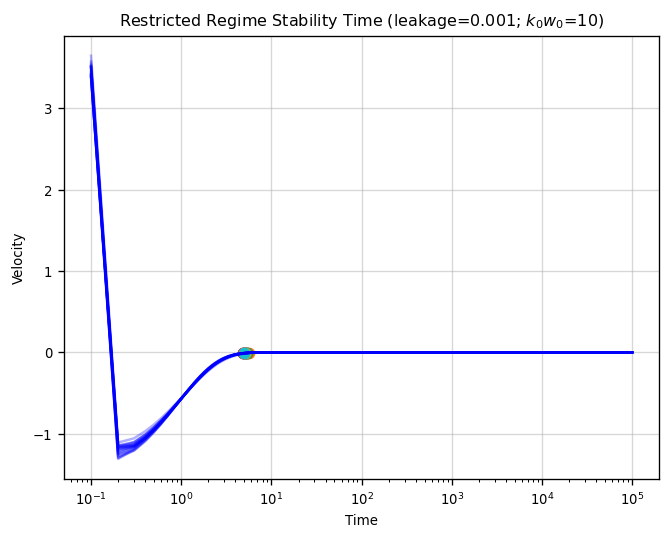

In [8]:
for i in range(num_simulations):
    plt.scatter(R_t_star_list[i], R_v_star_list[i])
    plt.plot(t[1:], R_t_diff_tot_star_list[i], c='blue', alpha=0.3)
plt.title('Restricted Regime Stability Time (leakage={}; $k_0w_0$={})'.format(inputs["leakage"],inputs["k_0"]))
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.xscale('log')
plt.grid(alpha=0.5);

### Set Simulations for *Diverse Regime*

In [9]:
# Diverse Regime
inputs["leakage"] = 0.8
inputs["k_0"] = 1000

In [10]:
num_simulations = 20
thr = 1e-2
D_t_star_list, D_v_star_list, D_t_diff_tot_star_list = [], [], []

for k in range(num_simulations):
    model=cmc3.CommunityModel(inputs)
#     model.ModelSeed(1234) 
    model.Simulate()
    clear_output(wait=True)
    print(f'Simulation {k} Done!')
    species = model.ReturnData("species")
    t_star, v_star, sp_diff_tot = find_stable_time(species, t, thr=thr)
    D_t_star_list.append(t_star)
    D_v_star_list.append(v_star)
    D_t_diff_tot_star_list.append(sp_diff_tot)

Simulation 19 Done!


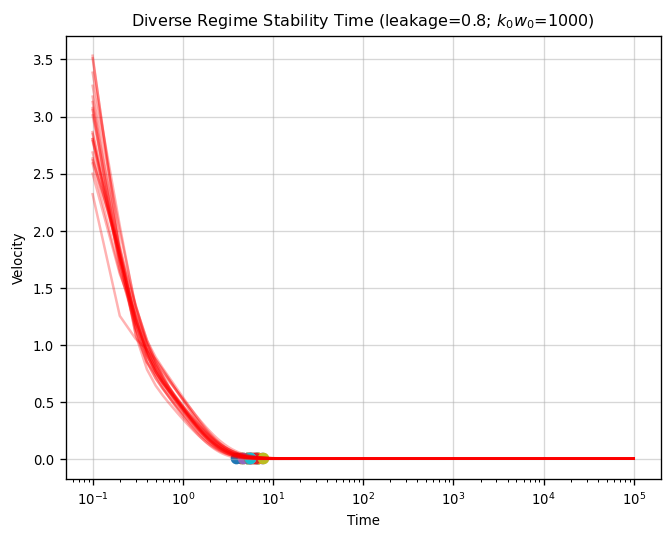

In [11]:
for i in range(num_simulations):
    plt.scatter(D_t_star_list[i], D_v_star_list[i])
    plt.plot(t[1:], D_t_diff_tot_star_list[i], c='red', alpha=0.3)
plt.title('Diverse Regime Stability Time (leakage={}; $k_0w_0$={})'.format(inputs["leakage"],inputs["k_0"]))
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.xscale('log')
plt.grid(alpha=0.5);

### Histograms

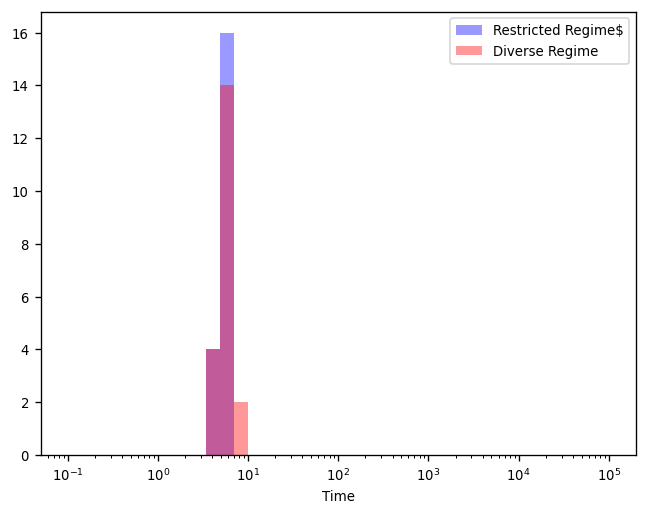

In [12]:
bins=np.logspace(np.log10(0.1),np.log10(inputs["time_period"]), 40)
plt.hist(R_t_star_list, bins=bins, color='blue', alpha=0.4, label='Restricted Regime')
plt.hist(D_t_star_list, bins=bins, color='red', alpha=0.4, label='Diverse Regime')
plt.xlabel('Time')
plt.xscale('log')
plt.legend();